# IDX-Trade — End-to-End Quant Showcase

**Cross-sectional alpha → frozen decision policy → execution-aware paper portfolio → performance, risk, and uncertainty.**

This notebook is a read-only presentation layer over canonical artifacts. It does not fit or tune a model, select features, place orders, mutate PaperState, call providers, or unlock protected outcomes.

```text
IDX market data + PIT / universe
              ↓
         frozen V4-X1 scorer
              ↓
          Decision V2
              ↓
           Sizing V1
              ↓
       execution preparation
              ↓
 official Open + CA verification
              ↓
          Execution V1
              ↓
           PaperState
              ↓
 alpha + portfolio analytics
```

### Modes

- `HISTORICAL_REPLAY` — authorized historical OOS alpha analysis. Historical executable portfolio replay is unavailable because the first session failed the frozen CA negative-authority contract.
- `FORWARD_LIVE` — current outcome-blind prospective monitoring artifacts only.
- `FORWARD_MATURED` — guarded interface for a separately authorized matured evaluation export; it fails closed until that export exists.

## 0 — Configuration and safety boundary

Set these environment variables before running the notebook. The notebook contains no personal absolute paths:

- `IDX_TRADE_SHOWCASE_MODE`: `HISTORICAL_REPLAY`, `FORWARD_LIVE`, or `FORWARD_MATURED`.
- `IDX_TRADE_HISTORICAL_OOS_ROOT`: authorized clean historical OOS export root.
- `IDX_TRADE_FORWARD_ROOT`: canonical outcome-blind `forward_monitoring` root.
- `IDX_TRADE_MATURED_ROOT`: optional explicitly authorized matured export; never point this at a protected vault.

Historical unresolved target states are excluded from realized-alpha metrics. Forward live never reads `alpha_outcomes.csv` or other realized-outcome artifacts.

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

_candidates = [Path.cwd(), *Path.cwd().parents]
REPO_ROOT = next((p for p in _candidates if (p / 'pyproject.toml').is_file()), None)
if REPO_ROOT is None:
    raise FileNotFoundError('Run the notebook from the IDX-Trade repository or one of its subdirectories.')
sys.path.insert(0, str(REPO_ROOT / 'src'))
sys.path.insert(0, str(REPO_ROOT / 'notebooks'))

from idx_trade.prospective_evaluation_v1 import (
    evaluate_alpha_metrics,
    evaluate_portfolio_metrics,
    moving_block_bootstrap_distribution,
)
from idx_trade_quant_showcase_support import (
    FORWARD_LIVE,
    FORWARD_MATURED,
    HISTORICAL_REPLAY,
    VALID_MODES,
    evaluate_historical_alpha_metrics,
    load_mode_artifacts,
    provenance_frame,
)

MODE = os.getenv('IDX_TRADE_SHOWCASE_MODE', HISTORICAL_REPLAY).strip().upper()
if MODE not in VALID_MODES:
    raise ValueError(f'MODE must be one of {sorted(VALID_MODES)}, got {MODE!r}')

BOOTSTRAP_BLOCK_LENGTH = 5
BOOTSTRAP_REPLICATES = 10_000
BOOTSTRAP_SEED = 20_260_824

run = load_mode_artifacts(
    MODE,
    historical_root=os.getenv('IDX_TRADE_HISTORICAL_OOS_ROOT'),
    forward_root=os.getenv('IDX_TRADE_FORWARD_ROOT'),
    matured_root=os.getenv('IDX_TRADE_MATURED_ROOT'),
    showcase_root=os.getenv('IDX_TRADE_SHOWCASE_ROOT'),
)

def _num(value, digits=3):
    try:
        value = float(value)
    except (TypeError, ValueError):
        return '—'
    return '—' if not np.isfinite(value) else f'{value:.{digits}f}'

def _pct(value, digits=2):
    try:
        value = float(value)
    except (TypeError, ValueError):
        return '—'
    return '—' if not np.isfinite(value) else f'{100 * value:.{digits}f}%'

print('mode:', MODE)
print('adapter status:', run.status)
print('message:', run.message)

mode: HISTORICAL_REPLAY
adapter status: READY
message: Authorized historical alpha loaded; executable portfolio intentionally unavailable.


## 1 — Executive snapshot

The headline alpha metrics are computed by the canonical prospective evaluator. Portfolio metrics appear only when a genuine canonical NAV artifact is present.

In [2]:
alpha_metrics = None
alpha_error = None
alpha_bootstrap_distribution = np.array([], dtype=float)
alpha_bootstrap_nonfinite = 0
portfolio_metrics = None
portfolio_error = None

if run.ready and not run.alpha_outcomes.empty:
    try:
        alpha_metrics = (
            evaluate_historical_alpha_metrics(run.alpha_outcomes)
            if MODE == HISTORICAL_REPLAY
            else evaluate_alpha_metrics(run.alpha_outcomes)
        )
        alpha_bootstrap_distribution, alpha_bootstrap_nonfinite = moving_block_bootstrap_distribution(
            alpha_metrics['session_ic']['ic'],
            lambda sample: float(np.mean(sample)),
            block_length=BOOTSTRAP_BLOCK_LENGTH,
            replicates=BOOTSTRAP_REPLICATES,
            seed=BOOTSTRAP_SEED,
        )
    except Exception as exc:
        alpha_error = str(exc)

if MODE == FORWARD_MATURED and run.ready and not run.nav.empty:
    try:
        portfolio_metrics = evaluate_portfolio_metrics(run.nav)
    except Exception as exc:
        portfolio_error = str(exc)

mean_ic = alpha_metrics.get('mean_ic') if alpha_metrics else None
ci = alpha_metrics.get('bootstrap_ci_95', [None, None]) if alpha_metrics else [None, None]
snapshot = pd.DataFrame([
    ['Mode', MODE],
    ['Adapter status', run.status],
    ['Sessions recorded', run.metadata.get('session_count', len(run.sessions))],
    ['Valid alpha rows', run.metadata.get('valid_alpha_rows', '—')],
    ['Mean Spearman IC', _num(mean_ic)],
    ['IC 95% moving-block CI', f'[{_num(ci[0], 4)}, {_num(ci[1], 4)}]'],
    ['ICIR', _num(alpha_metrics.get('icir') if alpha_metrics else None)],
    ['Positive IC sessions', _pct(alpha_metrics.get('positive_ic_fraction') if alpha_metrics else None)],
    ['Historical executable portfolio', 'UNAVAILABLE — EXECUTION AUTHORITY NOT PROVEN' if MODE == HISTORICAL_REPLAY else '—'],
], columns=['Metric', 'Value'])
display(snapshot)
if alpha_error:
    display(Markdown(f'**Alpha metrics blocked:** `{alpha_error}`'))
if portfolio_error:
    display(Markdown(f'**Portfolio metrics blocked:** `{portfolio_error}`'))

,Metric,Value
0,Mode,HISTORICAL_REPLAY
1,Adapter status,READY
2,Sessions recorded,600
3,Valid alpha rows,152171
4,Mean Spearman IC,0.098
5,IC 95% moving-block CI,"[0.0762, 0.1206]"
6,ICIR,0.630
7,Positive IC sessions,72.83%
8,Historical executable portfolio,UNAVAILABLE — EXECUTION AUTHORITY NOT PROVEN


## 2 — Alpha quality

This section uses only authorized historical OOS target rows. It reports mean/median/std IC, ICIR, positive-session fraction, fixed top-10/top-20 outcomes, and the frozen rank buckets. In `FORWARD_LIVE`, realized alpha remains locked.

,Metric,Value
0,Sessions,600
1,Rows,152171
2,Mean IC,0.098
3,Median IC,0.095
4,IC std,0.155
5,ICIR,0.630
6,Positive IC,72.83%


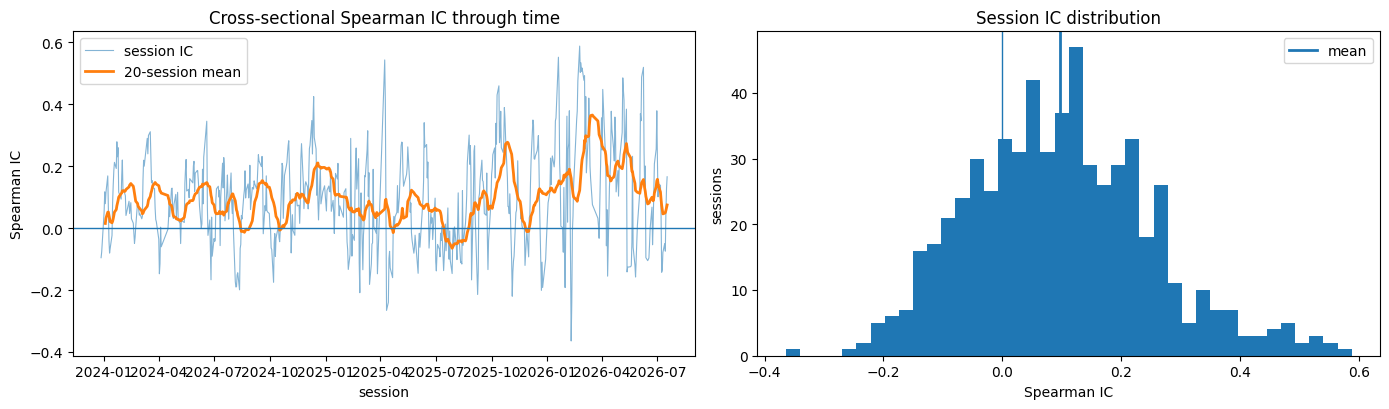

,Rank bucket,Sessions,Rows,Mean outcome,Median outcome
0,1–10,600,5332,0.543263,0.539116
1,11–20,600,5287,0.534035,0.529208
2,21–50,600,15726,0.525503,0.523275
3,>50,600,125826,0.493288,0.493125


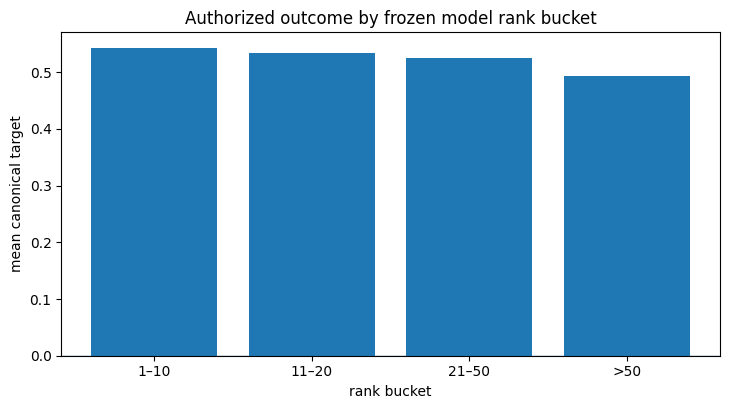

,Selection,Sessions,Mean outcome,Median outcome,95% bootstrap CI
0,Top-10,600,0.543263,0.539116,"[0.5295903526296629, 0.55698090593187]"
1,Top-20,600,0.538308,0.532516,"[0.5262650289069517, 0.5506991198610768]"


In [3]:
if MODE == FORWARD_LIVE:
    display(Markdown("""### 🔒 Outcome locked

`FORWARD_LIVE` does not read realized forward outcomes."""))
elif alpha_metrics is None:
    display(Markdown('No authorized alpha outcome frame is available in this mode.'))
else:
    headline = pd.DataFrame({
        'Metric': ['Sessions', 'Rows', 'Mean IC', 'Median IC', 'IC std', 'ICIR', 'Positive IC'],
        'Value': [
            alpha_metrics['session_count'],
            alpha_metrics['row_count'],
            _num(alpha_metrics['mean_ic']),
            _num(alpha_metrics['median_ic']),
            _num(alpha_metrics['std_ic']),
            _num(alpha_metrics['icir']),
            _pct(alpha_metrics['positive_ic_fraction']),
        ],
    })
    display(headline)

    ic = alpha_metrics['session_ic'].copy()
    ic['rolling_20'] = ic['ic'].rolling(20, min_periods=5).mean()
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
    axes[0].plot(ic['session_date'], ic['ic'], linewidth=0.8, alpha=0.55, label='session IC')
    axes[0].plot(ic['session_date'], ic['rolling_20'], linewidth=2, label='20-session mean')
    axes[0].axhline(0, linewidth=1)
    axes[0].set_title('Cross-sectional Spearman IC through time')
    axes[0].set_xlabel('session')
    axes[0].set_ylabel('Spearman IC')
    axes[0].legend()
    axes[1].hist(ic['ic'], bins=40)
    axes[1].axvline(alpha_metrics['mean_ic'], linewidth=2, label='mean')
    axes[1].axvline(0, linewidth=1)
    axes[1].set_title('Session IC distribution')
    axes[1].set_xlabel('Spearman IC')
    axes[1].set_ylabel('sessions')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    bucket_order = ['RANK_1_10', 'RANK_11_20', 'RANK_21_50', 'RANK_GT50']
    bucket_labels = ['1–10', '11–20', '21–50', '>50']
    bucket_table = pd.DataFrame([
        [label, alpha_metrics['rank_buckets'][key]['session_count'], alpha_metrics['rank_buckets'][key]['row_count'], alpha_metrics['rank_buckets'][key]['mean'], alpha_metrics['rank_buckets'][key]['median']]
        for key, label in zip(bucket_order, bucket_labels)
    ], columns=['Rank bucket', 'Sessions', 'Rows', 'Mean outcome', 'Median outcome'])
    display(bucket_table)
    plt.figure(figsize=(8.5, 4.2))
    plt.bar(bucket_table['Rank bucket'], bucket_table['Mean outcome'])
    plt.axhline(0, linewidth=1)
    plt.title('Authorized outcome by frozen model rank bucket')
    plt.xlabel('rank bucket')
    plt.ylabel('mean canonical target')
    plt.show()

    top_table = pd.DataFrame([
        [key.replace('TOP_', 'Top-'), value['session_count'], value['mean'], value['median'], value['bootstrap_ci_95']]
        for key, value in alpha_metrics['top_k'].items()
    ], columns=['Selection', 'Sessions', 'Mean outcome', 'Median outcome', '95% bootstrap CI'])
    display(top_table)

## 3 — Signal → portfolio

The notebook displays score and downstream artifacts when they genuinely exist. It does not infer decisions, orders, fills, or positions from score rows.

In [4]:
if not run.ready:
    display(Markdown('No canonical bundle is ready for this mode.'))
elif run.scores.empty:
    display(Markdown('No canonical score artifact is available.'))
else:
    latest = run.scores['session_date'].max()
    latest_scores = run.scores.loc[run.scores['session_date'].eq(latest)].copy()
    preferred = ['ticker', 'rank', 'alpha_consensus', 'score_status', 'model_fingerprint']
    columns = [column for column in preferred if column in latest_scores.columns]
    display(Markdown(f'**Latest score session:** `{latest.date()}` — {len(latest_scores)} rows'))
    display(latest_scores[columns].head(20) if columns else latest_scores.head(20))

    downstream = {
        'Decision V2': run.decisions,
        'prepared orders': run.orders,
        'fills': run.fills,
        'positions': run.positions,
    }
    absent = [name for name, frame in downstream.items() if frame.empty]
    if absent:
        display(Markdown('**Downstream artifacts unavailable:** ' + ', '.join(absent) + '. No score-to-portfolio inference was performed.'))

**Latest score session:** `2026-07-17` — 303 rows

,ticker,rank,alpha_consensus
172394,REAL,1,1.000000
172395,JGLE,2,0.993377
172396,WMUU,3,0.991722
172397,NETV,4,0.988411
172398,GOTO,5,0.980132
172399,POWR,6,0.978477
172400,BSSR,7,0.970199
172401,SMSM,8,0.961921
172402,ARNA,9,0.955298
172403,CLEO,10,0.943709


**Downstream artifacts unavailable:** Decision V2, prepared orders, fills, positions. No score-to-portfolio inference was performed.

## Canonical system architecture

`Market/PIT → frozen V4-X1 scorer → Decision V2 → Sizing V1 → execution preparation → official Open verification → CA/dividend verification → Execution V1 → PaperState → portfolio analytics`

For the accepted historical export, alpha is available but the execution replay authority is blocked at the CA negative/no-event evidence boundary. This notebook therefore does not manufacture historical portfolio performance.

## 4 — Portfolio performance

Portfolio metrics are descriptive and are shown only for a genuine canonical NAV series.

In [5]:
if MODE == FORWARD_MATURED and not run.nav.empty and portfolio_metrics is not None:
    display(pd.DataFrame([
        ['Net total return', _pct(portfolio_metrics.get('net_total_return'))],
        ['Annualized volatility', _pct(portfolio_metrics.get('annualized_volatility'))],
        ['Sharpe (rf=0)', _num(portfolio_metrics.get('sharpe_0'))],
        ['Sortino (rf=0)', _num(portfolio_metrics.get('sortino_0'))],
        ['Max drawdown', _pct(portfolio_metrics.get('max_drawdown'))],
        ['Calmar', _num(portfolio_metrics.get('calmar'))],
    ], columns=['Portfolio metric', 'Value']))
else:
    if MODE == HISTORICAL_REPLAY:
        display(Markdown("""## HISTORICAL EXECUTABLE PORTFOLIO

**UNAVAILABLE — EXECUTION AUTHORITY NOT PROVEN**

Reason: historical CA negative/no-event authority is insufficient for the frozen execution contract.

Blocked decision: `2023-12-28`  
Blocked execution: `2023-12-29`  
Verdict: `FIRST_HISTORICAL_E2E_SESSION_BLOCKED_BY_CA_NEGATIVE_AUTHORITY`

No historical fills, positions, NAV, Sharpe, Sortino, Calmar, cost, turnover, benchmark P&L, or live-portfolio claim is displayed. Historical alpha is authorized OOS research, not historical live paper performance."""))
    elif MODE == FORWARD_LIVE:
        display(Markdown("""## FORWARD LIVE PAPER PORTFOLIO

**UNAVAILABLE — CANONICAL PAPERSTATE/NAV ARTIFACT NOT FOUND**

The current outcome-blind monitoring export contains session and score evidence only."""))
    else:
        display(Markdown("""## FORWARD MATURED PORTFOLIO

**FORWARD_MATURED DATA NOT AVAILABLE**"""))

## HISTORICAL EXECUTABLE PORTFOLIO

**UNAVAILABLE — EXECUTION AUTHORITY NOT PROVEN**

Reason: historical CA negative/no-event authority is insufficient for the frozen execution contract.

Blocked decision: `2023-12-28`  
Blocked execution: `2023-12-29`  
Verdict: `FIRST_HISTORICAL_E2E_SESSION_BLOCKED_BY_CA_NEGATIVE_AUTHORITY`

No historical fills, positions, NAV, Sharpe, Sortino, Calmar, cost, turnover, benchmark P&L, or live-portfolio claim is displayed. Historical alpha is authorized OOS research, not historical live paper performance.

## 5 — Execution and cost drag

This section never estimates a replacement slippage model. It displays canonical execution summaries only when present.

In [6]:
if run.execution.empty:
    display(Markdown('**Execution and costs unavailable:** no canonical execution summary artifact is present.'))
else:
    display(run.execution.head(20))

**Execution and costs unavailable:** no canonical execution summary artifact is present.

## 6 — Robustness and statistical uncertainty

The frozen confirmatory uncertainty method is a moving-block bootstrap over the ordered session-level IC series: block length 5, 10,000 replicates, deterministic seed 20260824. The portfolio is not simulated to 252 sessions and no synthetic NAV Monte Carlo is used.

,Bootstrap quantity,Value
0,Method,Moving-block bootstrap over ordered session IC
1,Block length,5
2,Replicates,10000
3,Seed,20260824
4,Mean of bootstrap means,0.0981
5,P2.5,0.0762
6,Median,0.0979
7,P97.5,0.1206
8,P(mean > 0),100.00%
9,Non-finite replicates,0


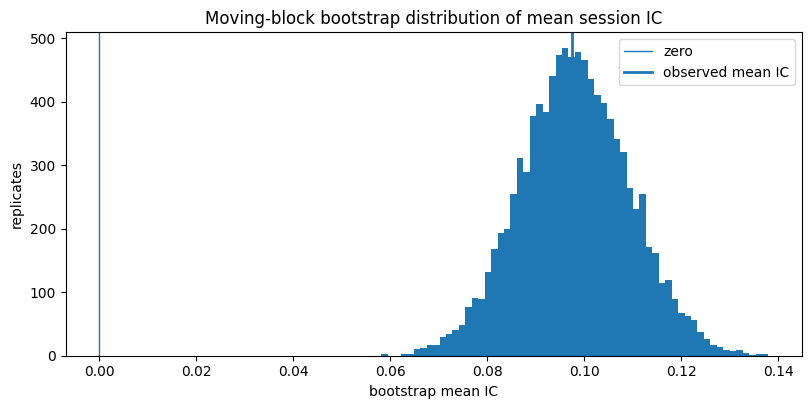

Portfolio risk uncertainty is unavailable because no genuine canonical NAV series is present.

In [7]:
if alpha_metrics is None:
    display(Markdown('Bootstrap alpha uncertainty is unavailable in this mode; forward realized outcomes remain locked.'))
else:
    finite_bootstrap = alpha_bootstrap_distribution[np.isfinite(alpha_bootstrap_distribution)]
    bootstrap_summary = pd.DataFrame([
        ['Method', 'Moving-block bootstrap over ordered session IC'],
        ['Block length', BOOTSTRAP_BLOCK_LENGTH],
        ['Replicates', BOOTSTRAP_REPLICATES],
        ['Seed', BOOTSTRAP_SEED],
        ['Mean of bootstrap means', _num(np.mean(finite_bootstrap), 4) if len(finite_bootstrap) else 'INCONCLUSIVE_STATISTICS'],
        ['P2.5', _num(np.quantile(finite_bootstrap, 0.025), 4) if len(finite_bootstrap) else '—'],
        ['Median', _num(np.median(finite_bootstrap), 4) if len(finite_bootstrap) else '—'],
        ['P97.5', _num(np.quantile(finite_bootstrap, 0.975), 4) if len(finite_bootstrap) else '—'],
        ['P(mean > 0)', _pct(np.mean(finite_bootstrap > 0)) if len(finite_bootstrap) else '—'],
        ['Non-finite replicates', alpha_bootstrap_nonfinite],
    ], columns=['Bootstrap quantity', 'Value'])
    display(bootstrap_summary)
    plt.figure(figsize=(9.5, 4.2))
    plt.hist(alpha_bootstrap_distribution, bins=60)
    plt.axvline(0, linewidth=1, label='zero')
    plt.axvline(alpha_metrics['mean_ic'], linewidth=2, label='observed mean IC')
    plt.title('Moving-block bootstrap distribution of mean session IC')
    plt.xlabel('bootstrap mean IC')
    plt.ylabel('replicates')
    plt.legend()
    plt.show()
    if run.nav.empty:
        display(Markdown('Portfolio risk uncertainty is unavailable because no genuine canonical NAV series is present.'))

## 7 — Forward live monitor

`FORWARD_LIVE` may show recorded session progress, model identity, score status, input provenance, and integrity/admission state. Realized forward outcomes and matured performance remain outcome-locked.

In [8]:
if MODE == FORWARD_LIVE and run.ready:
    monitor_keys = [
        'latest_session', 'session_count', 'score_sessions', 'model_id',
        'model_generation', 'model_fingerprint', 'model_status',
        'outcome_access', 'forward_outcomes_accessed', 'provider_calls_from_x1',
    ]
    display(pd.DataFrame([[key, run.metadata.get(key, 'UNAVAILABLE')] for key in monitor_keys], columns=['Forward monitor', 'Value']))
    display(run.field_status)
    display(Markdown("""### 🔒 Outcome locked

No realized forward alpha, hidden labels, protected P&L, or matured evaluation result was read."""))
elif MODE == FORWARD_MATURED:
    display(Markdown('**FORWARD_MATURED DATA NOT AVAILABLE** — the guarded loader requires a separate explicitly authorized matured export.'))
else:
    display(Markdown('Forward live monitor is not active in this mode.'))

Forward live monitor is not active in this mode.

## 8 — Research integrity

The integrity table makes the boundary observable: `historical_alpha_authorized = true` for the clean OOS export, while `historical_execution_authority = false` after the accepted CA negative-authority verdict.

In [9]:
integrity_rows = [
    ['mode', MODE],
    ['historical_alpha_authorized', run.metadata.get('historical_alpha_authorized', 'NOT_APPLICABLE')],
    ['historical_execution_authority', run.metadata.get('historical_execution_authority', 'NOT_APPLICABLE')],
    ['actual_live_historical_portfolio', run.metadata.get('actual_live_historical_portfolio', False)],
    ['forward_outcome_access', run.integrity.get('forward_outcome_access', 'LOCKED')],
    ['PaperState mutation', run.integrity.get('paperstate_mutation', False)],
    ['provider calls', run.integrity.get('provider_calls', False)],
    ['synthetic evidence', run.integrity.get('synthetic_evidence', False)],
    ['target / CA integrity', run.integrity.get('target_contract', run.integrity.get('ca_input_basis', 'UNAVAILABLE'))],
]
display(pd.DataFrame(integrity_rows, columns=['Integrity contract', 'Status']))
display(Markdown('### Field-level availability'))
display(run.field_status)

sources = provenance_frame(run)
if not sources.empty:
    display(Markdown('### Source provenance and hashes'))
    display(sources)

display(Markdown('**Notebook boundary:** local reads, canonical metric aggregation, hashing, and visualization only. No provider, outcome-vault, PaperState, counter, order, or runtime mutation occurs here.'))

,Integrity contract,Status
0,mode,HISTORICAL_REPLAY
1,historical_alpha_authorized,True
2,historical_execution_authority,False
3,actual_live_historical_portfolio,False
4,forward_outcome_access,LOCKED / NOT ACCESSED
5,PaperState mutation,False
6,provider calls,False
7,synthetic evidence,False
8,target / CA integrity,"Unresolved target states are excluded, never t..."


### Field-level availability

,Field,Status,Evidence
0,historical alpha,AVAILABLE,Authorized clean historical OOS score/target e...
1,historical executable portfolio,BLOCKED,CA negative/no-event authority is not proven
2,historical fills/positions/NAV,NOT_APPLICABLE,Execution replay is intentionally not attempted
3,forward realized outcomes,BLOCKED,Protected prospective outcomes remain locked
4,PaperState mutation,NOT_APPLICABLE,Notebook is read-only
5,provider calls,NOT_APPLICABLE,Adapter performs local reads only


### Source provenance and hashes

,role,path,sha256,size_bytes,rows
0,clean historical challenger scores,<configured-root>/clean_challenger_validation_...,48ea8932de3405155550aabcb982ebe325bf0caa9ce573...,5136511,172697.0
1,clean target ledger,<configured-root>/clean_target_ledger.parquet,e333089fd1cf170f830112c52f17274b2bd528cf4002a2...,5865763,345770.0
2,historical OOS access boundary,<configured-root>/HISTORICAL_OOS_ACCESS_BOUNDA...,c213cfbf62f73d85ed5998edb1b9fb96d948cbc41ab613...,569,NaN
3,historical OOS manifest,<configured-root>/MANIFEST.json,6573a563bb1c408bd32cdd00f9ae8aaba654d5fec96e6a...,5095,NaN


**Notebook boundary:** local reads, canonical metric aggregation, hashing, and visualization only. No provider, outcome-vault, PaperState, counter, order, or runtime mutation occurs here.

### Interpretation guide

Historical alpha is an authorized OOS research result. It must not be described as historical live paper performance because the first executable session remains blocked by insufficient CA negative/no-event authority. `FORWARD_LIVE` is the canonical source for current outcome-blind paper state when genuine PaperState artifacts become available. `FORWARD_MATURED` remains fail-closed until an authorized matured export exists.